In [1]:
import cmcrameri.cm as cmc
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import time
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [2]:
%run GEOS5functions.py
%matplotlib inline 

In [3]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

# Set the current storm index to ???
currentstorm = 17

In [4]:
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

timesel = slice(starttime,endtime)
extended_timesel = slice(starttime - datetime.timedelta(days=5) ,endtime + datetime.timedelta(days=5))
degbuffer = 20
latsel = slice(lat1-degbuffer,lat2+degbuffer)
lonsel = slice(lon1-degbuffer,lon2+degbuffer)

In [5]:
timesel

slice(datetime.datetime(2006, 8, 18, 10, 0), datetime.datetime(2006, 8, 30, 15, 0), None)

In [6]:
extended_timesel

slice(datetime.datetime(2006, 8, 13, 10, 0), datetime.datetime(2006, 9, 4, 15, 0), None)

In [7]:
stormname = stormlist[1][currentstorm][0:9]
print(stormname)

atl06tc01


In [8]:
stormtraj = np.load('/home/modares/TC/trajectory/' + str(stormname)+'.npz')
minpres = stormtraj['minpres']
timee = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

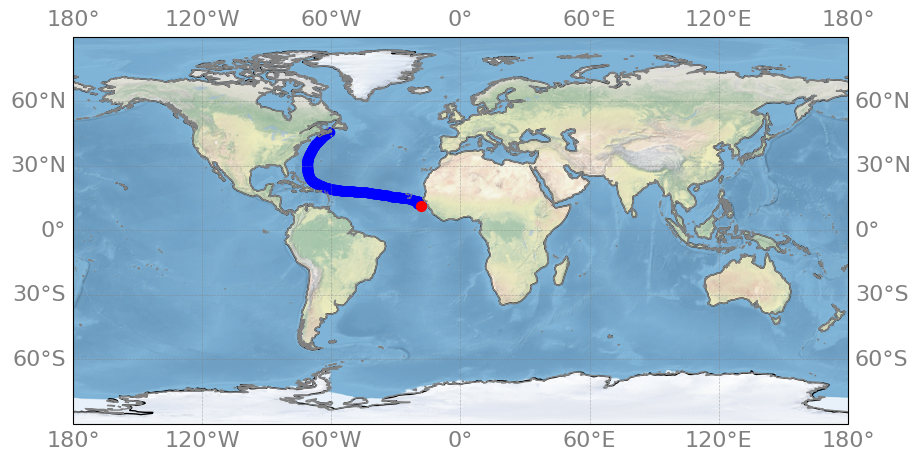

In [9]:
fig = plt.figure(figsize=(10,6))
crs0 = ccrs.PlateCarree(central_longitude=0)
ax = fig.add_subplot(1, 1, 1, projection=crs0)
#ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=crs0)

#####

#ax.set_extent([60, 120, -20, 20], crs=crs0)
ax.stock_img()
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.OCEAN)

ax.add_feature(cfeature.LAND)
#####

ax.coastlines()
ax.coastlines('50m', color='gray', edgecolor='white')
gl = ax.gridlines(crs=crs0, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlabel_style = {'size':16,'color':'gray'}
gl.ylabel_style = {'size':16,'color':'gray'}

# Plot all points
plt.scatter(minplon, minplat, color='blue', transform=ccrs.PlateCarree())

# Highlight first point in red
plt.scatter(minplon[0], minplat[0], color='red', s=50, zorder=5, transform=ccrs.PlateCarree())

plt.show()

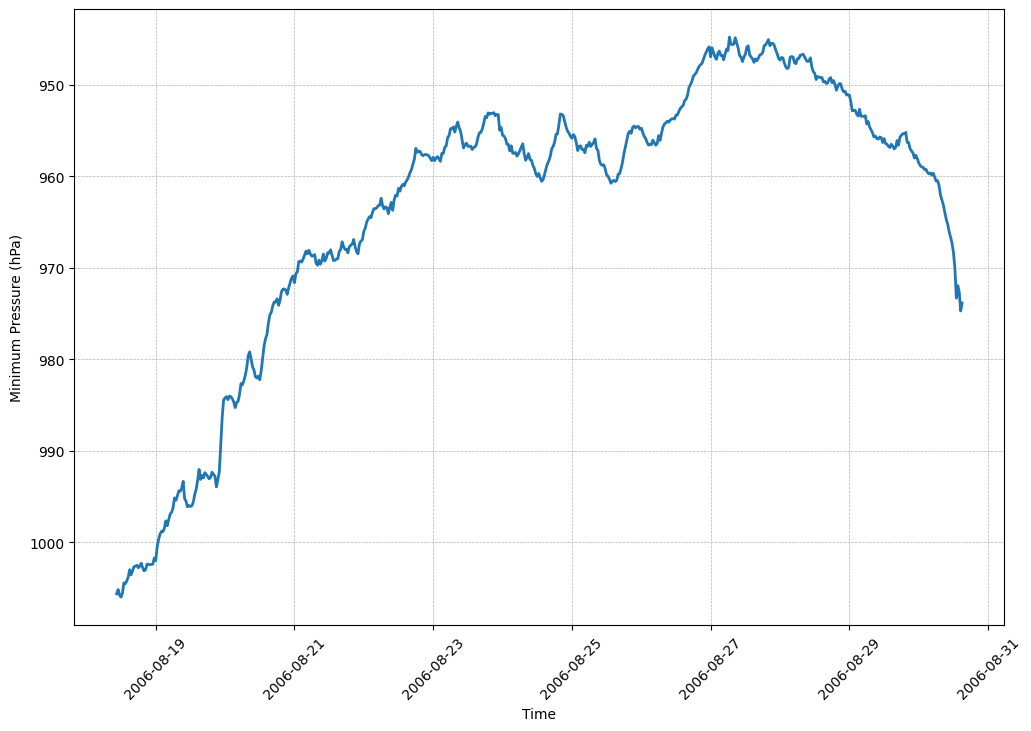

In [10]:
minpres = stormtraj['minpres']
timee = stormtraj['time']

fig, ax = plt.subplots(figsize=(12, 8))

plt.plot(timee, minpres/100,linewidth=2 )

plt.xlabel('Time')
plt.ylabel('Minimum Pressure (hPa)')

plt.grid(True, which='both', linestyle='--', linewidth=0.5)

ax.invert_yaxis()
plt.xticks(rotation=45)

#plt.savefig('npc06tc01_intensity.png', bbox_inches='tight', transparent=True)


plt.show()

In [11]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['U', 'V', 'SO4', 'CLOUD', 'PL', 'T', 'DELP', 'SO4', 'SO2', 'BCPHOBIC','BCPHILIC', 'H', 'W']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_3d_' + varvec[vind] + '_Nv'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'U':
        dsu = xr.open_dataset(url)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'V':
        dsv = xr.open_dataset(url)  # Open dataset for 'V' (meridional wind component)
    if varvec[vind] == 'SO4':
        dsso4 = xr.open_dataset(url)  # Open dataset for 'DELP' (surface pressure and pressure thickness)
    if varvec[vind] == 'CLOUD':
        dscloud = xr.open_dataset(url)
    if varvec[vind] == 'PL':
        dspl = xr.open_dataset(url)
    if varvec[vind] == 'T':
        dst = xr.open_dataset(url)
    if varvec[vind] == 'DELP':
        dsdelp = xr.open_dataset(url)
    if varvec[vind] == 'H':
        dsh = xr.open_dataset(url)


#varmet = ['troppt']

url2 = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_2d_met1_Nx'

dsmet = xr.open_dataset(url2)


# Print a success message indicating that the datasets have been read successfully
print('success reading')

# URL for accessing the land mask dataset
landurl = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/const/const_2d_asm_Nx'
# Open the land mask dataset
dsland = xr.open_dataset(landurl)

# Display the land mask dataset information


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-pack

success reading


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/xarray/coding/times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


In [12]:
dsmet['troppt']

<xarray.DataArray 'troppt' (time: 36576, lat: 2881, lon: 5760)> Size: 2TB
[606962626560 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 293kB 2005-05-15T21:30:00.000003 ... 2007-...
  * lat      (lat) float64 23kB -90.0 -89.94 -89.88 -89.81 ... 89.88 89.94 90.0
  * lon      (lon) float64 46kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
Attributes:
    units:      Pa
    long_name:  tropopause_pressure_based_on_thermal_estimate

In [13]:
'''

# Select latitude, longitude, time, and level data from the datasets based on the specified slices

lat = dsso4['lat'].sel(lat=latsel)  # Select latitude values within the range specified by 'latsel'
lon = dsso4['lon'].sel(lon=lonsel)  # Select longitude values within the range specified by 'lonsel'
time = dsso4['time'].sel(time=timesel)  # Select time values within the range specified by 'timesel'
lev = dsu['lev']  # Select the vertical levels (pressure levels) from the 'dsu' dataset

# Select surface pressure ('ps') from the dataset based on the time, latitude, and longitude selections
#ps = dsdelp['ps'].sel(time=timesel, lat=latsel, lon=lonsel)
delp = dsdelp['delp'].sel(time=timesel, lat=latsel, lon=lonsel)
pl = dspl['pl'].sel(time=timesel, lat=latsel, lon=lonsel)
#h = h['h'].sel(time=timesel, lat=latsel, lon=lonsel)
tempt = dst['t'].sel(time=timesel, lat=latsel, lon=lonsel)
so4 = dsso4['so4'].sel(time=timesel, lat=latsel, lon=lonsel)
u = dsu['u'].sel(time=timesel, lat=latsel, lon=lonsel)
v = dsv['v'].sel(time=timesel, lat=latsel, lon=lonsel)
'''

# Select latitude, longitude, time, and level data from the datasets based on the specified slices

#lat = dsso4['lat'].sel(lat=latsel)  # Select latitude values within the range specified by 'latsel'
#lon = dsso4['lon'].sel(lon=lonsel)  # Select longitude values within the range specified by 'lonsel'
#time = dsso4['time'].sel(time=timesel)  # Select time values within the range specified by 'timesel'
lev = dsu['lev']  # Select the vertical levels (pressure levels) from the 'dsu' dataset

# Select surface pressure ('ps') from the dataset based on the time, latitude, and longitude selections
#ps = dsdelp['ps'].sel(time=timesel, lat=latsel, lon=lonsel)
#delp = dsdelp['delp'].sel(time=timesel, lat=latsel, lon=lonsel)
#pl = dspl['pl'].sel(time=timesel, lat=latsel, lon=lonsel)
#h = h['h'].sel(time=timesel, lat=latsel, lon=lonsel)
#tempt = dst['t'].sel(time=timesel, lat=latsel, lon=lonsel)
#so4 = dsso4['so4'].sel(time=timesel, lat=latsel, lon=lonsel)
#u = dsu['u'].sel(time=timesel, lat=latsel, lon=lonsel)
#v = dsv['v'].sel(time=timesel, lat=latsel, lon=lonsel)

### Extended
variable = 'so4'

time = dsso4['time'].sel(time= extended_timesel )
so4 = dsso4[variable].sel(time= extended_timesel )
delp = dsdelp['delp'].sel(time= extended_timesel )

In [14]:
dsh['h'].sel(lev= 38).isel(time = 36500, lat = 100, lon =100).values

array(14758.168, dtype=float32)

In [15]:
extended_timesel

slice(datetime.datetime(2006, 8, 13, 10, 0), datetime.datetime(2006, 9, 4, 15, 0), None)

In [16]:
timesel = timee
len(timesel)

586

In [17]:
bufferrr = 2.5

In [18]:
first_value = minplat[0]  
last_value = minplat[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplat = np.concatenate([prefix_array, minplat, suffix_array])
extended_minplat.size

1066

In [19]:
first_value = minplon[0]  
last_value = minplon[-1]  

# Create arrays of 48 elements with the first and last values
prefix_array = np.full(240, first_value)
suffix_array = np.full(240, last_value)

# Concatenate the arrays
extended_minplon = np.concatenate([prefix_array, minplon, suffix_array])
extended_minplon.size

1066

In [20]:
extended_timee = dsso4['time'].sel(time= extended_timesel) 

In [21]:
extended_timee

<xarray.DataArray 'time' (time: 1066)> Size: 9kB
array(['2006-08-13T10:30:00.000000000', '2006-08-13T11:00:00.000003000',
       '2006-08-13T11:29:59.999997000', ..., '2006-09-04T14:00:00.000003000',
       '2006-09-04T14:29:59.999997000', '2006-09-04T15:00:00.000000000'],
      shape=(1066,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T15:...
Attributes:
    grads_dim:      t
    grads_mapping:  linear
    grads_size:     36576
    grads_min:      21:30z15may2005
    grads_step:     30mn
    long_name:      time
    minimum:        21:30z15may2005
    maximum:        21z16jun2007
    resolution:     0.020833334

In [22]:


u_values, v_values, delp_values, so4_values = extract_values_with_buffer(
    dsv, dsu, delp, so4, extended_minplat, extended_minplon, extended_timee, lev, buffer = bufferrr
)



# Total flux plots

In [39]:
dataset_gph = xr.open_dataset('interpolated_gpheight_so4_atl06tc01_box5.0_futures_extended_correctinterp.nc')
dataset_gph = dataset_gph.isel(time=slice(1, None))
gph = dataset_gph['total_flux']


In [44]:
gph

<xarray.DataArray 'total_flux' (time: 1065, pressure: 72)> Size: 613kB
[76680 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 9kB 2006-08-13T11:00:00.000003 ... 2006-0...
  * pressure  (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04
Attributes:
    units:      original_units
    long_name:  Total flux interpolated to pressure levels

In [40]:

dataset_so4 = xr.open_dataset('interpolated_Concentration_so4_atl06tc01_box5.0_futures_extended_correctintrp.nc')
so4 = dataset_so4['total_flux']


In [41]:
so4

<xarray.DataArray 'total_flux' (time: 1065, pressure: 72)> Size: 613kB
[76680 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 9kB 2006-08-13T11:00:00.000003 ... 2006-0...
  * pressure  (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04
Attributes:
    units:      original_units
    long_name:  Total flux interpolated to pressure levels

In [42]:

dataset_so2 = xr.open_dataset('interpolated_Concentration_so2_atl06tc01_box5.0_futures_extended_correctintrp.nc')
so2 = dataset_so4['total_flux']


In [43]:
so2

<xarray.DataArray 'total_flux' (time: 1065, pressure: 72)> Size: 613kB
[76680 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 9kB 2006-08-13T11:00:00.000003 ... 2006-0...
  * pressure  (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04
Attributes:
    units:      original_units
    long_name:  Total flux interpolated to pressure levels

In [45]:
import numpy as np

# Determine the length of extended_time
n = len(extended_timee)

# Pre-allocate the array to store the selected values
extended_minpress = np.zeros(n)

# Loop over each index
for i in range(n):
    extended_minpress[i] = dspl['pl'].sel(
        time=extended_timee[i],
        lat=extended_minplat[i],
        lon=extended_minplon[i],
        lev=72
    ).item()

In [50]:
new_ds = dataset_so2  * (28.96/64.066) * 1e+6 # SO2

In [52]:
new_ds = dataset_so4 * (28.96/96.06) * 1e+6

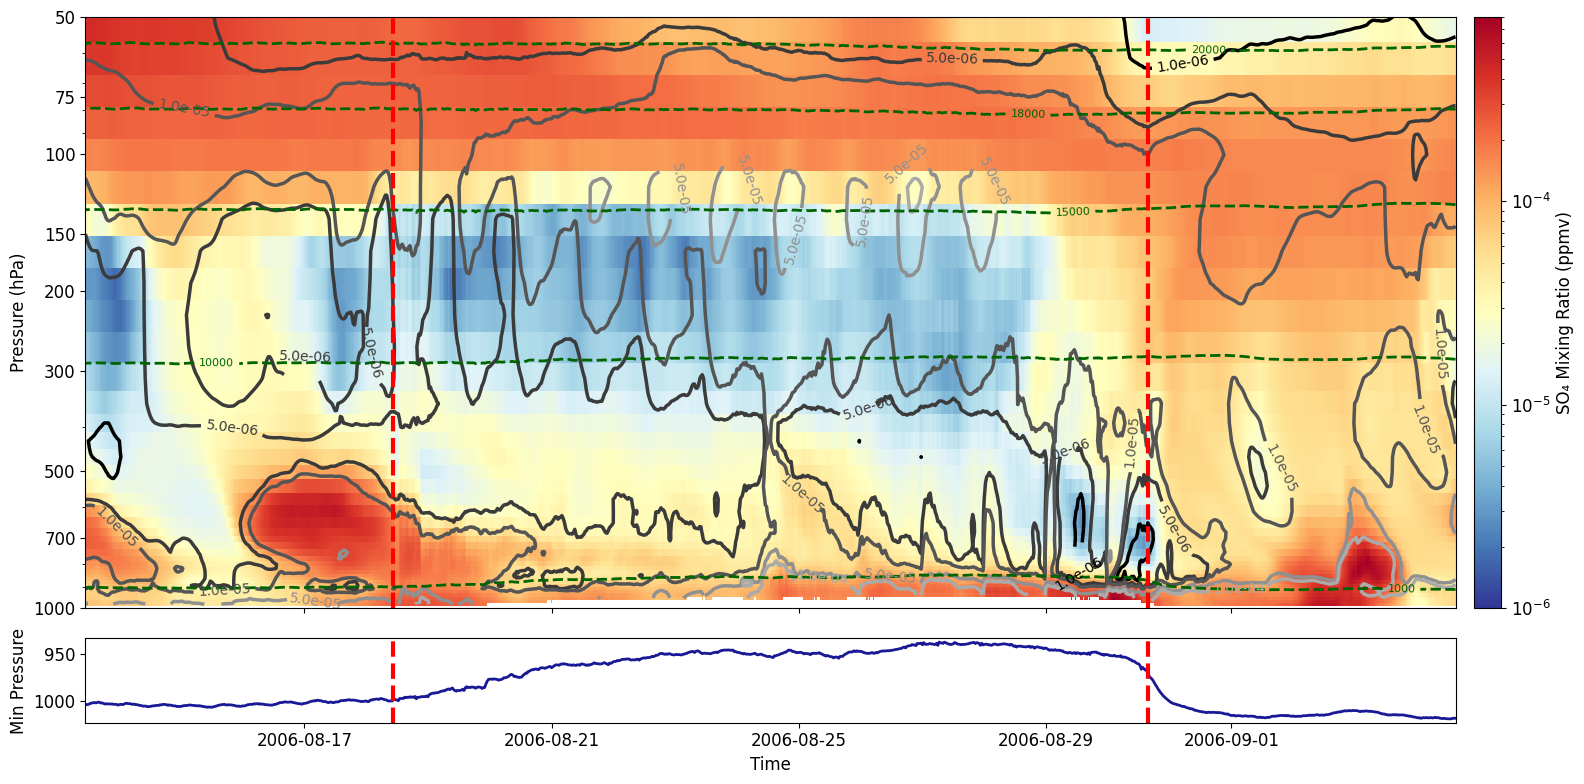

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
from matplotlib.ticker import LogLocator


mpl.rcParams.update({'font.size': 12})  # Change 12 to your preferred base size


# Slice the DataArray for lev between 30 and 70
#new_ds = new_ds.isel(lev=slice(25, 72))

time_numeric = new_ds['time']
lev_sel = new_ds['pressure']

# Convert xarray time to numpy datetime
time_values = time_numeric.values  # Extract time values as numpy datetime64
storm_time_values = stormtraj['time']  # No need for .values

# Create figure with GridSpec
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[7, 1])

# Define axes: ax1 and ax2 share x-axis, cax is for colorbar
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[0, 1])

# **Top Plot: Contour Plot for Total Flux**

so4_flux = new_ds.total_flux

flux_min = 1e-6 #so4_flux.where(so4_flux > 0).min().item()  # Avoid zero values
flux_max = so4_flux.where(so4_flux > 0).max().item()


contour = ax1.pcolormesh(new_ds.time, new_ds.pressure /100, so4_flux.T, 
                 cmap='RdYlBu_r', norm=mcolors.LogNorm(vmin= flux_min, vmax= flux_max))

ax1.set_ylabel('Pressure (hPa)')
#ax1.set_title('Contour Plot of Total Flux (lev 30-72) vs Time')
ax1.set_ylim([50,1000])
ax1.invert_yaxis()  # Reverse y-axis for levels
ax1.set_yscale('log')


# Define major and minor ticks for the logarithmic scale
ax1.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))  # Major ticks at powers of 10
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))  # Minor ticks

# Explicitly set y-ticks at custom pressure levels
custom_ticks = [1000, 700, 500, 300, 200, 150, 100, 75, 50]
ax1.set_yticks(custom_ticks)
ax1.set_yticklabels([str(int(tick)) for tick in custom_ticks])  # Convert to string labels




ax1.set_xlabel('')  # Removes the x-axis label from ax1
ax1.tick_params(labelbottom=False)  # Hides tick labels on the x-axis of ax1





# Add colorbar in separate axes
fig.colorbar(contour, cax=cax, label='SO₄ Mixing Ratio (ppmv)')

# **Bottom Plot: Line Plot for Minimum Pressure**
ax2.plot(extended_timee, extended_minpress / 100, color='darkblue', alpha=0.9,  linewidth=2)  # Convert Pa to hPa
ax2.set_ylabel('Min Pressure')
ax2.set_xlabel('Time')
ax2.invert_yaxis()  # Pressure decreases upwards


# Set x-axis formatter on ax2 (since it displays the labels with sharex=True)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ensure both plots share the same x-axis limits
ax2.set_xlim(time_values.min(), time_values.max())


# Adjust layout
plt.tight_layout()

####
other_flux = dataset_so2.total_flux * (28.96/64.066) * 1e+6

flux_min = 1e-6 #so4_flux.where(so4_flux > 0).min().item()  # Avoid zero values
flux_max = 1e-3 # other_flux.where(so4_flux > 0).max().item()



# Mask or log-transform if needed, to match the log scale
contour_levels = [1e-6 ,5* 1e-6, 1e-5, 5* 1e-5 , 1e-4 ] # np.logspace(np.log10(flux_min), np.log10(flux_max), 7)  # Adjust number of contour levels

contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    cmap='gist_gray',  # Or any colormap like 'viridis', 'inferno', etc.
    linewidths=2.5,
    linestyles='solid',
    norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max)
)

# Optional: add labels to contour lines
ax1.clabel(contour_lines, fmt='%1.1e', fontsize=10)


other_flux = dataset_gph.total_flux 

flux_min =  so4_flux.where(so4_flux > 0).min().item()  # Avoid zero values
flux_max =  other_flux.where(so4_flux > 0).max().item()




# Mask or log-transform if needed, to match the log scale
contour_levels = [1000 , 10000, 15000, 18000, 20000] # np.logspace(np.log10(flux_min), np.log10(flux_max), 10)  # Adjust number of contour levels

contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    colors='darkgreen',         # or another color for contrast
    linewidths=2,
    linestyles='dashed',     # could also be 'dashed', etc.
    norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max)  # Match log scaling
)

# Optional: add labels to contour lines
ax1.clabel(contour_lines, fontsize=8)


# Add vertical red lines at specified time steps
if len(time_values) > 5:
    ax1.axvline(time_values[239], color='red', linestyle='--', linewidth=3)
    ax1.axvline(time_values[-240], color='red', linestyle='--', linewidth=3)
    ax2.axvline(time_values[239], color='red', linestyle='--', linewidth=3)
    ax2.axvline(time_values[-240], color='red', linestyle='--', linewidth=3)







buffer = 5

# Save figure
#plt.savefig(f'{stormname}_Box{buffer}_' + 'SO2overSO4_Concentration_vs_Time_vs_Pressure_extended.png', bbox_inches='tight', transparent=True)

plt.show()

# Modified Color

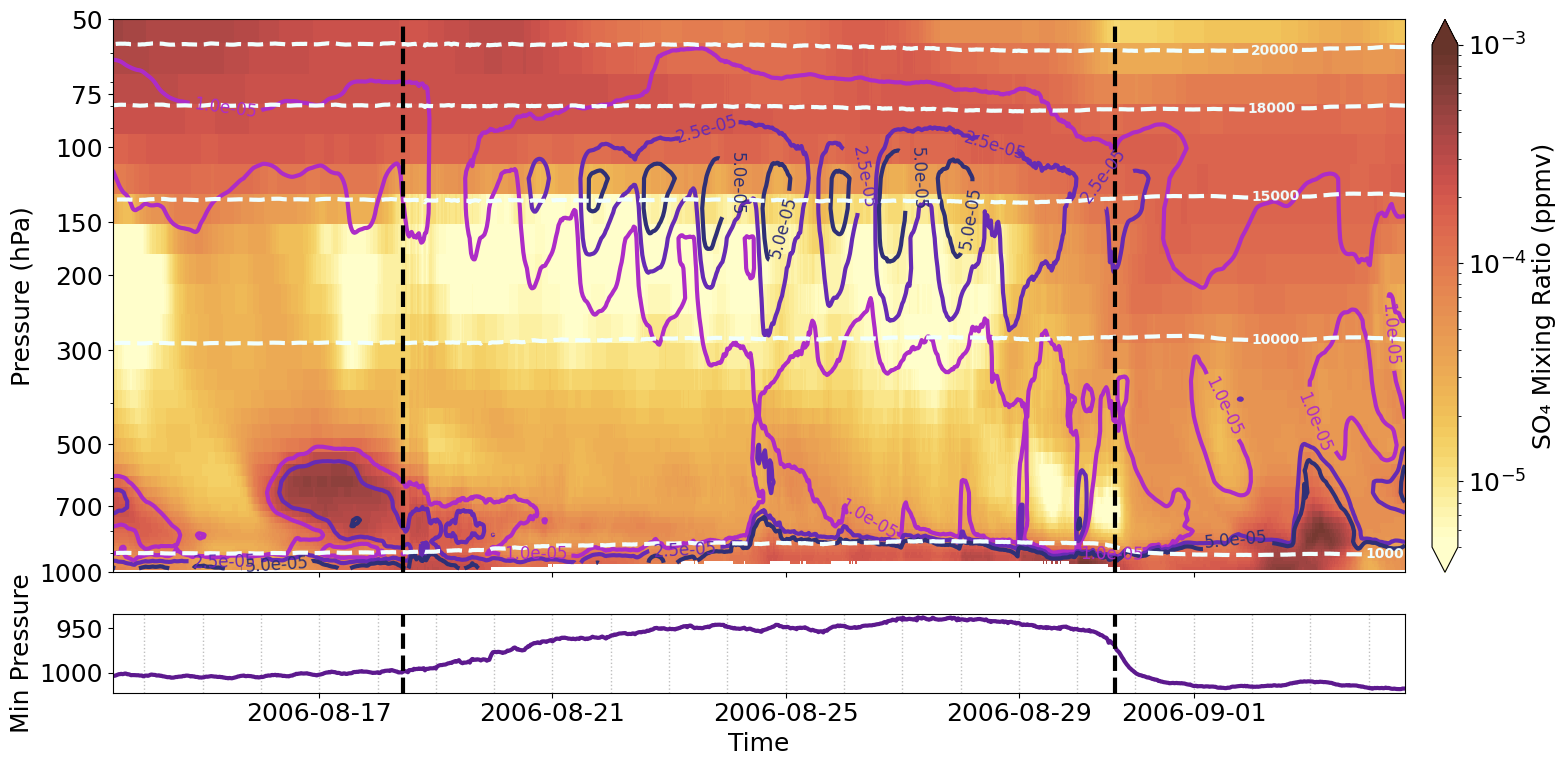

In [63]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
from matplotlib.ticker import LogLocator
import matplotlib.colors as mcolors
import numpy as np
from datetime import timedelta
import pandas as pd
from matplotlib.font_manager import FontProperties
import colormaps as cmaps 


mpl.rcParams.update({'font.size': 18})

# Convert to colorblind-friendly settings
time_numeric = new_ds['time']
lev_sel = new_ds['pressure']

# Convert xarray time to numpy datetime
time_values = time_numeric.values
storm_time_values = stormtraj['time']

# Create figure with GridSpec
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[7, 1])

# Define axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[0, 1])

# **Top Plot: Contour Plot for Total Flux**
# Changed to colorblind-friendly colormap (viridis)
so4_flux = new_ds.total_flux

flux_min = 5 * 1e-6
flux_max = 1 * 1e-3 #so4_flux.where(so4_flux > 0).max().item()


contour = ax1.pcolormesh(new_ds.time, new_ds.pressure / 100, so4_flux.T, 
                         cmap=cmaps.lajolla_r.shift(-0.75), 
                         norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max))

ax1.set_ylabel('Pressure (hPa)')
ax1.set_ylim([50, 1000])
ax1.invert_yaxis()
ax1.set_yscale('log')

# Define major and minor ticks for the logarithmic scale
ax1.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Custom y-ticks
custom_ticks = [1000, 700, 500, 300, 200, 150, 100, 75, 50]
ax1.set_yticks(custom_ticks)
ax1.set_yticklabels([str(int(tick)) for tick in custom_ticks])

ax1.set_xlabel('')
ax1.tick_params(labelbottom=False)

# Add colorbar
fig.colorbar(contour, cax=cax, label='SO₄ Mixing Ratio (ppmv)', extend='both')

# **Bottom Plot: Line Plot for Minimum Pressure**
# Changed to a more distinguishable color (purple/magenta instead of dark blue)
ax2.plot(extended_timee, extended_minpress / 100, 
         color='indigo',  # Dark magenta - distinct from blue/green
         alpha=0.9, linewidth=3)

# Add vertical lines for diurnal cycle (every 24 hours)
# Convert numpy datetime64 to pandas datetime for easier manipulation
start_time = pd.Timestamp(time_values.min())
end_time = pd.Timestamp(time_values.max())

# Generate midnight times for each day
current_time = start_time.normalize()  # Round down to midnight
while current_time <= end_time:
    ax2.axvline(current_time, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
    current_time += timedelta(days=1)

# Optional: Add noon times (12-hour intervals) for finer resolution
# Uncomment the following lines if you want both midnight and noon markers
# current_time = start_time.normalize() + timedelta(hours=12)
# while current_time <= end_time:
#     ax2.axvline(current_time, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.3, zorder=1)
#     current_time += timedelta(days=1)

ax2.set_ylabel('Min Pressure')
ax2.set_xlabel('Time')
ax2.invert_yaxis()

# Set x-axis formatter
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ensure both plots share the same x-axis limits
ax2.set_xlim(time_values.min(), time_values.max())

# Adjust layout
plt.tight_layout()

#### SO2 Contours ####
other_flux = dataset_so2.total_flux * (28.96/64.066) * 1e+6

flux_min = 1e-6
flux_max = 1e-4

contour_levels = [ 1e-5, 2.5 * 1e-5 , 5*1e-5]

# Changed to black with thicker lines for better visibility
contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    cmap=cmaps.bubblegum_r,  # Or any colormap like 'viridis', 'inferno', etc.
    linewidths=3,
    linestyles='solid',
    norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max)
)

# Add labels to contour lines
ax1.clabel(contour_lines, fmt='%1.1e', fontsize=12)

#### Geopotential Height Contours ####
other_flux = dataset_gph.total_flux 

flux_min = so4_flux.where(so4_flux > 0).min().item()
flux_max = other_flux.where(so4_flux > 0).max().item()

contour_levels = [1000, 10000,15000, 18000, 20000]

# Changed to orange dashed lines - distinct from black and visible on viridis
contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    colors='azure',  # Dark orange - distinct and colorblind-friendly
    linewidths=3,
    linestyles='dashed'
)

# Add labels to contour lines
labels = ax1.clabel(contour_lines, fontsize=10)

# Make all labels bold
for txt in labels:
    txt.set_fontweight('bold')


# Add vertical lines at specified time steps
# Changed to magenta to match the pressure line and avoid red/green confusion
if len(time_values) > 5:
    ax1.axvline(time_values[239], color='black', linestyle='--', linewidth=3)  # Deep pink
    ax1.axvline(time_values[-240], color='black', linestyle='--', linewidth=3)
    ax2.axvline(time_values[239], color='black', linestyle='--', linewidth=3)
    ax2.axvline(time_values[-240], color='black', linestyle='--', linewidth=3)

buffer = 5

# Save figure
plt.savefig(f'{stormname}_Box{buffer}_' + 'SO2overSO4_Concentration_vs_Time_vs_Pressure_extended_colorblind.png', 
            bbox_inches='tight', transparent=True)

plt.show()

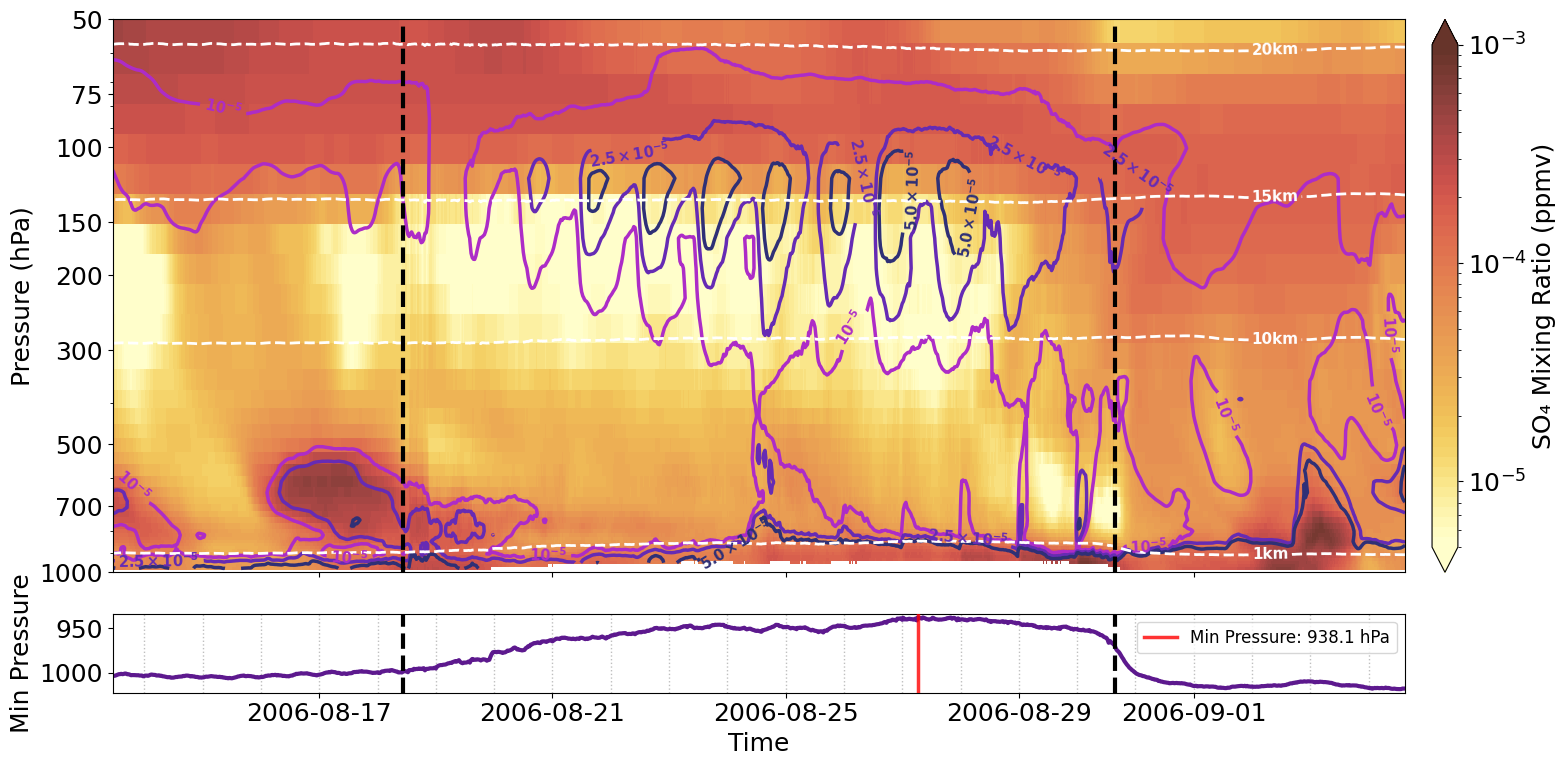

In [88]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
from matplotlib.ticker import LogLocator
import matplotlib.colors as mcolors
import numpy as np
from datetime import timedelta
import pandas as pd
from matplotlib.font_manager import FontProperties
import colormaps as cmaps 


mpl.rcParams.update({'font.size': 18})

# Convert to colorblind-friendly settings
time_numeric = new_ds['time']
lev_sel = new_ds['pressure']

# Convert xarray time to numpy datetime
time_values = time_numeric.values
storm_time_values = stormtraj['time']

# Create figure with GridSpec
fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.02], height_ratios=[7, 1])

# Define axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
cax = fig.add_subplot(gs[0, 1])

# **Top Plot: Contour Plot for Total Flux**
# Changed to colorblind-friendly colormap (viridis)
so4_flux = new_ds.total_flux

flux_min = 5 * 1e-6
flux_max = 1 * 1e-3 #so4_flux.where(so4_flux > 0).max().item()


contour = ax1.pcolormesh(new_ds.time, new_ds.pressure / 100, so4_flux.T, 
                         cmap=cmaps.lajolla_r.shift(-0.75), 
                         norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max))

ax1.set_ylabel('Pressure (hPa)')
ax1.set_ylim([50, 1000])
ax1.invert_yaxis()
ax1.set_yscale('log')

# Define major and minor ticks for the logarithmic scale
ax1.yaxis.set_major_locator(LogLocator(base=10.0, subs=None, numticks=10))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Custom y-ticks
custom_ticks = [1000, 700, 500, 300, 200, 150, 100, 75, 50]
ax1.set_yticks(custom_ticks)
ax1.set_yticklabels([str(int(tick)) for tick in custom_ticks])

ax1.set_xlabel('')
ax1.tick_params(labelbottom=False)

# Add colorbar
fig.colorbar(contour, cax=cax, label='SO₄ Mixing Ratio (ppmv)', extend='both')

# **Bottom Plot: Line Plot for Minimum Pressure**
# Changed to a more distinguishable color (purple/magenta instead of dark blue)
ax2.plot(extended_timee, extended_minpress / 100, 
         color='indigo',  # Dark magenta - distinct from blue/green
         alpha=0.9, linewidth=3)

# Find the time of minimum pressure
min_pressure_idx = np.argmin(extended_minpress)
min_pressure_time = extended_timee[min_pressure_idx]
# Extract the actual datetime value from xarray DataArray
if hasattr(min_pressure_time, 'values'):
    min_pressure_time = min_pressure_time.values
min_pressure_value = extended_minpress[min_pressure_idx] / 100

# Add vertical line at minimum pressure
ax2.axvline(min_pressure_time, color='red', linestyle='-', linewidth=2.5, 
            alpha=0.8, label=f'Min Pressure: {min_pressure_value:.1f} hPa', zorder=3)

# Add vertical lines for diurnal cycle (every 24 hours)
# Convert numpy datetime64 to pandas datetime for easier manipulation
start_time = pd.Timestamp(time_values.min())
end_time = pd.Timestamp(time_values.max())

# Generate midnight times for each day
current_time = start_time.normalize()  # Round down to midnight
while current_time <= end_time:
    ax2.axvline(current_time, color='gray', linestyle=':', linewidth=1, alpha=0.5, zorder=1)
    current_time += timedelta(days=1)

# Optional: Add noon times (12-hour intervals) for finer resolution
# Uncomment the following lines if you want both midnight and noon markers
# current_time = start_time.normalize() + timedelta(hours=12)
# while current_time <= end_time:
#     ax2.axvline(current_time, color='lightgray', linestyle=':', linewidth=0.5, alpha=0.3, zorder=1)
#     current_time += timedelta(days=1)

ax2.set_ylabel('Min Pressure')
ax2.set_xlabel('Time')
ax2.invert_yaxis()
ax2.legend(loc='best', fontsize=12)

# Set x-axis formatter
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Ensure both plots share the same x-axis limits
ax2.set_xlim(time_values.min(), time_values.max())

# Adjust layout
plt.tight_layout()

#### SO2 Contours ####
#### SO2 Contours ####
other_flux = dataset_so2.total_flux * (28.96/64.066) * 1e+6

flux_min = 1e-6
flux_max = 1e-4

contour_levels = [ 1e-5, 2.5 * 1e-5 , 5*1e-5]

# Changed to black with thicker lines for better visibility
contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    cmap=cmaps.bubblegum_r,
    linewidths=2.5,
    linestyles='solid',
    norm=mcolors.LogNorm(vmin=flux_min, vmax=flux_max)
)

# Custom formatter function to convert scientific notation to mathematical format
# Custom formatter function to convert scientific notation to mathematical format
def format_scientific(x):
    """Convert scientific notation to mathematical superscript format with bold font"""
    if x == 0:
        return r'$\mathbf{0}$'
    
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent
    
    # If mantissa is 1, just show 10^exp in bold
    if abs(mantissa - 1.0) < 1e-10:
        return rf'$\mathbf{{10^{{{exponent}}}}}$'
    # Otherwise show mantissa × 10^exp in bold
    else:
        return rf'$\mathbf{{{mantissa:.1f} \times 10^{{{exponent}}}}}$'

# Add labels to contour lines with custom formatting
labels = ax1.clabel(contour_lines, fmt=format_scientific, fontsize=10.5)

#################

#### Geopotential Height Contours ####
other_flux = dataset_gph.total_flux 

flux_min = so4_flux.where(so4_flux > 0).min().item()
flux_max = other_flux.where(so4_flux > 0).max().item()

contour_levels = [1000, 10000,15000, 20000]

# Changed to orange dashed lines - distinct from black and visible on viridis
contour_lines = ax1.contour(
    dataset_so4.time,
    dataset_so4.pressure / 100,
    other_flux.T,
    levels=contour_levels,
    colors='w',  # Dark orange - distinct and colorblind-friendly
    linewidths=2.0,
    linestyles='dashed'
)

# Add labels to contour lines with custom formatting

# Use inline=False to place labels at the end of contours (typically right side)
labels = ax1.clabel(contour_lines, fontsize=11, 
                   fmt={1000: '1km', 10000: '10km', 15000: '15km', 20000: '20km'})

# Make all labels bold
for txt in labels:
    txt.set_fontweight('bold')


# Add vertical lines at specified time steps
# Changed to magenta to match the pressure line and avoid red/green confusion
if len(time_values) > 5:
    ax1.axvline(time_values[239], color='black', linestyle='--', linewidth=3)  # Deep pink
    ax1.axvline(time_values[-240], color='black', linestyle='--', linewidth=3)
    ax2.axvline(time_values[239], color='black', linestyle='--', linewidth=3)
    ax2.axvline(time_values[-240], color='black', linestyle='--', linewidth=3)

buffer = 5

# Save figure
plt.savefig(f'{stormname}_Box{buffer}_' + 'SO2overSO4_Concentration_vs_Time_vs_Pressure_extended_colorblind.png', 
            bbox_inches='tight', transparent=True)

plt.show()

# add height

In [23]:
h = dsh['h'].sel(time= extended_timesel, lat= latsel, lon= lonsel)

In [24]:

hsel = []

# Loop through each time step
for t in range(len(extended_minplat)):
    
    hsell = dsh['h'].sel( time= extended_timesel, lat = extended_minplat[t], lon = extended_minplon[t]).isel(time= t)
    
    hsel.append(hsell)


In [25]:
hsel_da = xr.DataArray(
        data=hsel,
        dims=['time', 'lev'],
        coords={
        'time': [hsel[t].time.values for t in range(len(hsel))],
        'lev': hsel[0].lev.values
        },
        name='plsel_da'
        )

In [26]:

plsel = []

# Loop through each time step
for t in range(len(extended_minplat)):
    
    plsell = dspl['pl'].sel( time= extended_timesel, lat = extended_minplat[t], lon = extended_minplon[t]).isel(time= t)
    
    plsel.append(plsell)


In [27]:
plsel_da = xr.DataArray(
        data=plsel,
        dims=['time', 'lev'],
        coords={
        'time': [plsel[t].time.values for t in range(len(plsel))],
        'lev': plsel[0].lev.values
        },
        name='plsel_da'
        )

In [28]:
plsel_da

<xarray.DataArray 'plsel_da' (time: 1066, lev: 72)> Size: 307kB
array([[1.50000012e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.72652812e+04, 9.87564375e+04, 1.00276688e+05],
       [1.50000012e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.72462344e+04, 9.88017344e+04, 1.00322984e+05],
       [1.50000012e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.72766094e+04, 9.88318516e+04, 1.00353250e+05],
       ...,
       [1.50000024e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.86940938e+04, 1.00248047e+05, 1.01770812e+05],
       [1.50000024e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.86977500e+04, 1.00252641e+05, 1.01776891e+05],
       [1.50000024e+00, 2.63500023e+00, 4.01425076e+00, ...,
        9.86275156e+04, 1.00182344e+05, 1.01770516e+05]],
      shape=(1066, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T15:...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0

In [29]:
hsel_da

<xarray.DataArray 'plsel_da' (time: 1066, lev: 72)> Size: 307kB
array([[7.6942805e+04, 7.3339078e+04, 7.0663750e+04, ..., 3.3906094e+02,
        2.0228351e+02, 6.7088150e+01],
       [7.6929250e+04, 7.3355531e+04, 7.0704625e+04, ..., 3.3914709e+02,
        2.0219748e+02, 6.7029663e+01],
       [7.7038547e+04, 7.3459438e+04, 7.0807938e+04, ..., 3.3878683e+02,
        2.0188173e+02, 6.6975830e+01],
       ...,
       [7.6978547e+04, 7.3423414e+04, 7.0780812e+04, ..., 3.2326022e+02,
        1.9273611e+02, 6.4437302e+01],
       [7.6812125e+04, 7.3358797e+04, 7.0801719e+04, ..., 3.2360669e+02,
        1.9289854e+02, 6.4410156e+01],
       [7.6755977e+04, 7.3278766e+04, 7.0729609e+04, ..., 3.2402576e+02,
        1.9310938e+02, 6.4524445e+01]], shape=(1066, 72), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T15:...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0

In [30]:
merged_ds = xr.Dataset({
    "hsel_da": hsel_da,
    "plsel_da": plsel_da
})

In [31]:
merged_ds

<xarray.Dataset> Size: 623kB
Dimensions:   (time: 1066, lev: 72)
Coordinates:
  * time      (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T15...
  * lev       (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 69.0 70.0 71.0 72.0
Data variables:
    hsel_da   (time, lev) float32 307kB 7.694e+04 7.334e+04 ... 193.1 64.52
    plsel_da  (time, lev) float32 307kB 1.5 2.635 4.014 ... 1.002e+05 1.018e+05

In [32]:
# new interp

In [33]:
"""
Quick example: Interpolate flux data to pressure levels
"""
import xarray as xr
import numpy as np
from scipy.interpolate import interp1d

# Assuming your dataset is named 'ds'
# ds = your xarray Dataset

def quick_interpolate(ds):
    """
    Quick interpolation of total_flux_da to fixed pressure grid.
    Uses mean pressure at each level as the target grid.
    """
    # Extract data
    plsel = ds['plsel_da'].values  # (1065, 72)
    flux = ds['hsel_da'].values  # (1065, 72)
    time = ds['time'].values
    
    # Define target pressure levels (mean at each level)
    target_pressures = np.mean(plsel, axis=0)  # (72,)
    
    # Initialize output
    flux_interp = np.zeros((len(time), len(target_pressures)))
    
    # Interpolate each time step
    for i in range(len(time)):
        # Sort by pressure (required for interpolation)
        sort_idx = np.argsort(plsel[i, :])
        p_sorted = plsel[i, sort_idx]
        f_sorted = flux[i, sort_idx]
        
        # Interpolate
        interp_func = interp1d(p_sorted, f_sorted, kind='linear',
                               bounds_error=False, fill_value=np.nan)
        flux_interp[i, :] = interp_func(target_pressures)
    
    # Create new dataset
    ds_new = xr.Dataset(
        data_vars={
            'total_flux': (['time', 'pressure'], flux_interp,
                          {'units': 'original_units', 
                           'long_name': 'Total flux interpolated to pressure levels'})
        },
        coords={
            'time': ('time', time),
            'pressure': ('pressure', target_pressures, 
                        {'units': 'Pa', 'long_name': 'Pressure level'})
        }
    )
    
    return ds_new

# Usage:
# ds_interpolated = quick_interpolate(ds)
# print(ds_interpolated)

# Access interpolated data:
# flux_on_pressure = ds_interpolated['total_flux']
# pressure_levels = ds_interpolated['pressure']

In [34]:
ds_interpolated = quick_interpolate(merged_ds)

In [35]:
ds_interpolated

<xarray.Dataset> Size: 623kB
Dimensions:     (time: 1066, pressure: 72)
Coordinates:
  * time        (time) datetime64[ns] 9kB 2006-08-13T10:30:00 ... 2006-09-04T...
  * pressure    (pressure) float32 288B 1.5 2.635 4.014 ... 9.645e+04 9.793e+04
Data variables:
    total_flux  (time, pressure) float64 614kB 7.694e+04 7.334e+04 ... 383.9

In [36]:
new_ds = ds_interpolated

In [37]:
new_ds.to_netcdf('interpolated_gpheight_{variable}_{stormname}_box{buffer}_futures_extended_correctinterp.nc'.format(stormname=stormname, buffer=2*bufferrr, variable = variable))

In [ ]:
# end new interp